# Heston MV/Bartlett Delta Integration Budget Sweep

This notebook checks whether the MV/Bartlett delta baseline is already near its numerical asymptote. It uses the same Heston market, seed, and 5k test paths as `heston_comparison copy 3.ipynb`, computes MV hedge ratios for several Gauss-Legendre integration budgets, and replays each hedge under `cost=0` and `cost=1e-3`.

In [1]:
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.samplers import HestonSampler
from src.deltas import HestonMVDeltaHedger

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Same Heston cell as the comparison notebooks.
S0 = 100.0
v0 = 0.04
r = 0.01
kappa = 2.0
theta = 0.04
xi = 0.1
rho = -0.7
T = 1.0
N = 30
K = 100.0
a = 1.0
M_val = 5_000
M_test = 5_000

OUT_DIR = Path('results_mv_budget')
HEDGE_DIR = OUT_DIR / 'hedges'
OUT_DIR.mkdir(exist_ok=True)
HEDGE_DIR.mkdir(exist_ok=True)

# Recreate exactly the same test paths: seed, then val sample, then test sample.
sampler = HestonSampler(S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, xi=xi, rho=rho, T=T, N=N)
np.random.seed(42)
_ = sampler.sample(M_val)
paths_test = sampler.sample(M_test)
paths_test_t = torch.tensor(paths_test, dtype=torch.float64, device=DEVICE)

def load_metric(root, method):
    p = Path(root) / f'{method}.json'
    row = json.loads(p.read_text())[-1]
    return float(row.get('test_softmin', row.get('val_loss')))

DH_DEVIATION = {
    0.0: load_metric('results_heston_cf_mv_copy3_cost0', 'DH-Deviation'),
    1e-3: load_metric('results_heston_cf_mv_copy3', 'DH-Deviation'),
}
print('DH-Deviation references:', DH_DEVIATION)


Device: cuda


DH-Deviation references: {0.0: 8.957175254821777, 0.001: 9.159543991088867}


In [2]:
def softmin_np(pnl, a=1.0):
    x = -a * np.asarray(pnl)
    m = np.max(x)
    return float((np.log(np.exp(x - m).mean()) + m) / a)

def choose_batch_size(n_quad):
    if n_quad <= 1024:
        return 5000
    if n_quad <= 4096:
        return 1024
    return 512

def compute_mv_hedges(n_quad, phi_max, batch_size=None):
    batch_size = choose_batch_size(n_quad) if batch_size is None else batch_size
    hedger = HestonMVDeltaHedger(
        K=K, r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        T=T, N=N, cost=0.0, n_quad=n_quad, phi_max=phi_max,
        device=DEVICE, dtype=torch.float64, batch_size=batch_size,
    )
    M = paths_test.shape[0]
    hedges = np.empty((M, N), dtype=np.float64)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for t in range(N):
        tau = T - t * (T / N)
        S_t = paths_test_t[:, t, 0]
        v_t = paths_test_t[:, t, 1]
        delta, vega = hedger._delta_vega_torch(S_t, v_t, tau)
        hedge = hedger._hedge_from_greeks(S_t.to(device=hedger.device, dtype=hedger.dtype), delta, vega)
        hedges[:, t] = hedge.detach().cpu().numpy()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return hedges, elapsed

def backtest_from_hedges(hedges, cost):
    S = paths_test[:, :, 0]
    cash = np.zeros(S.shape[0], dtype=np.float64)
    delta_prev = np.zeros(S.shape[0], dtype=np.float64)
    fees_total = np.zeros(S.shape[0], dtype=np.float64)
    for t in range(N):
        delta_t = hedges[:, t]
        d_delta = delta_t - delta_prev
        cash -= d_delta * S[:, t]
        fees = cost * np.abs(d_delta) * S[:, t]
        cash -= fees
        fees_total += fees
        delta_prev = delta_t
    cash += delta_prev * S[:, -1]
    pnl = cash - np.clip(S[:, -1] - K, 0, None)
    return pnl, fees_total

def config_label(n_quad, phi_max):
    return f'q{n_quad}_phi{int(phi_max)}'

quad_curve = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
configs = [{'n_quad': q, 'phi_max': 200.0, 'kind': 'node_curve'} for q in quad_curve]
configs += [
    {'n_quad': 2048, 'phi_max': 50.0, 'kind': 'truncation_check'},
    {'n_quad': 2048, 'phi_max': 100.0, 'kind': 'truncation_check'},
    {'n_quad': 4096, 'phi_max': 400.0, 'kind': 'truncation_check'},
    {'n_quad': 8192, 'phi_max': 100.0, 'kind': 'truncation_check'},
    {'n_quad': 8192, 'phi_max': 400.0, 'kind': 'truncation_check'},
    {'n_quad': 8192, 'phi_max': 800.0, 'kind': 'truncation_check'},
]
# Deduplicate while preserving order.
seen = set()
configs_unique = []
for cfg in configs:
    key = (cfg['n_quad'], cfg['phi_max'])
    if key not in seen:
        seen.add(key)
        cfg = dict(cfg)
        cfg['label'] = config_label(cfg['n_quad'], cfg['phi_max'])
        cfg['batch_size'] = choose_batch_size(cfg['n_quad'])
        configs_unique.append(cfg)
configs = configs_unique
print(pd.DataFrame(configs))


    n_quad  phi_max              kind         label  batch_size
0       16    200.0        node_curve    q16_phi200        5000
1       32    200.0        node_curve    q32_phi200        5000
2       64    200.0        node_curve    q64_phi200        5000
3      128    200.0        node_curve   q128_phi200        5000
4      256    200.0        node_curve   q256_phi200        5000
5      512    200.0        node_curve   q512_phi200        5000
6     1024    200.0        node_curve  q1024_phi200        5000
7     2048    200.0        node_curve  q2048_phi200        1024
8     4096    200.0        node_curve  q4096_phi200        1024
9     8192    200.0        node_curve  q8192_phi200         512
10    2048     50.0  truncation_check   q2048_phi50        1024
11    2048    100.0  truncation_check  q2048_phi100        1024
12    4096    400.0  truncation_check  q4096_phi400        1024
13    8192    100.0  truncation_check  q8192_phi100         512
14    8192    400.0  truncation_check  q

In [3]:
hedges_by_label = {}
elapsed_by_label = {}

for cfg in configs:
    label = cfg['label']
    hedge_path = HEDGE_DIR / f'{label}.npy'
    meta_path = HEDGE_DIR / f'{label}.json'
    if hedge_path.exists() and meta_path.exists():
        hedges = np.load(hedge_path)
        meta = json.loads(meta_path.read_text())
        elapsed = float(meta['elapsed_compute_sec'])
        print(f'loaded {label}: elapsed={elapsed:.3f}s')
    else:
        print(f'computing {label}: n_quad={cfg["n_quad"]}, phi_max={cfg["phi_max"]}, batch={cfg["batch_size"]}')
        hedges, elapsed = compute_mv_hedges(cfg['n_quad'], cfg['phi_max'], cfg['batch_size'])
        np.save(hedge_path, hedges)
        meta_path.write_text(json.dumps({**cfg, 'elapsed_compute_sec': elapsed}, indent=2))
        print(f'  done {label}: elapsed={elapsed:.3f}s')
    hedges_by_label[label] = hedges
    elapsed_by_label[label] = elapsed

ref_label = 'q8192_phi400'
ref = hedges_by_label[ref_label]
rows = []
for cfg in configs:
    label = cfg['label']
    hedges = hedges_by_label[label]
    diff = hedges - ref
    rmse_vs_ref = float(np.sqrt(np.mean(diff ** 2)))
    max_abs_vs_ref = float(np.max(np.abs(diff)))
    for cost in [0.0, 1e-3]:
        pnl, fees = backtest_from_hedges(hedges, cost)
        soft = softmin_np(pnl, a=a)
        rows.append({
            **cfg,
            'cost': cost,
            'cost_label': 'cost0' if cost == 0.0 else 'cost10bp',
            'softmin': soft,
            'mean_pnl': float(np.mean(pnl)),
            'std_pnl': float(np.std(pnl)),
            'fees_mean': float(np.mean(fees)),
            'elapsed_compute_sec': float(elapsed_by_label[label]),
            'rmse_delta_vs_ref': rmse_vs_ref,
            'max_abs_delta_vs_ref': max_abs_vs_ref,
            'dh_deviation_softmin': DH_DEVIATION[cost],
            'gap_vs_dh_deviation': soft - DH_DEVIATION[cost],
        })

df = pd.DataFrame(rows)
for cost in [0.0, 1e-3]:
    ref_soft = float(df[(df['label'] == ref_label) & (df['cost'] == cost)]['softmin'].iloc[0])
    df.loc[df['cost'] == cost, 'gap_vs_ref_mv'] = df.loc[df['cost'] == cost, 'softmin'] - ref_soft

csv_path = OUT_DIR / 'mv_budget_sweep.csv'
df.to_csv(csv_path, index=False)
(OUT_DIR / 'mv_budget_sweep.json').write_text(df.to_json(orient='records', indent=2))
print('saved', csv_path)
print(df.sort_values(['cost', 'softmin'])[['label','cost_label','softmin','gap_vs_ref_mv','gap_vs_dh_deviation','mean_pnl','std_pnl','fees_mean','elapsed_compute_sec','rmse_delta_vs_ref']].to_string(index=False))


computing q16_phi200: n_quad=16, phi_max=200.0, batch=5000


  done q16_phi200: elapsed=0.273s
computing q32_phi200: n_quad=32, phi_max=200.0, batch=5000
  done q32_phi200: elapsed=0.145s
computing q64_phi200: n_quad=64, phi_max=200.0, batch=5000


  done q64_phi200: elapsed=0.148s
computing q128_phi200: n_quad=128, phi_max=200.0, batch=5000
  done q128_phi200: elapsed=0.154s
computing q256_phi200: n_quad=256, phi_max=200.0, batch=5000


  done q256_phi200: elapsed=0.158s
computing q512_phi200: n_quad=512, phi_max=200.0, batch=5000


  done q512_phi200: elapsed=0.171s
computing q1024_phi200: n_quad=1024, phi_max=200.0, batch=5000


...

  done q2048_phi100: elapsed=0.744s
computing q4096_phi400: n_quad=4096, phi_max=400.0, batch=1024


  done q4096_phi400: elapsed=1.003s
computing q8192_phi100: n_quad=8192, phi_max=100.0, batch=512


  done q8192_phi100: elapsed=2.018s
computing q8192_phi400: n_quad=8192, phi_max=400.0, batch=512


  done q8192_phi400: elapsed=2.011s
computing q8192_phi800: n_quad=8192, phi_max=800.0, batch=512


  done q8192_phi800: elapsed=2.023s
saved results_mv_budget/mv_budget_sweep.csv
       label cost_label   softmin  gap_vs_ref_mv  gap_vs_dh_deviation  mean_pnl  std_pnl  fees_mean  elapsed_compute_sec  rmse_delta_vs_ref
q8192_phi100      cost0  9.196491  -7.634043e-05             0.239315 -7.914794 1.340805   0.000000             2.017988       2.728111e-04
q2048_phi100      cost0  9.196491  -7.634040e-05             0.239315 -7.914794 1.340805   0.000000             0.744433       2.728111e-04
q8192_phi200      cost0  9.196567  -1.629331e-08             0.239392 -7.914862 1.340793   0.000000             1.985312       2.335409e-07
q4096_phi200      cost0  9.196567  -1.624381e-08             0.239392 -7.914862 1.340793   0.000000             1.012643       2.335410e-07
q2048_phi200      cost0  9.196567  -1.622903e-08             0.239392 -7.914862 1.340793   0.000000             0.760862       2.335410e-07
 q128_phi200      cost0  9.196567  -1.621477e-08             0.239392 -7.914862 

saved results_mv_budget/mv_budget_softmin_curve.png


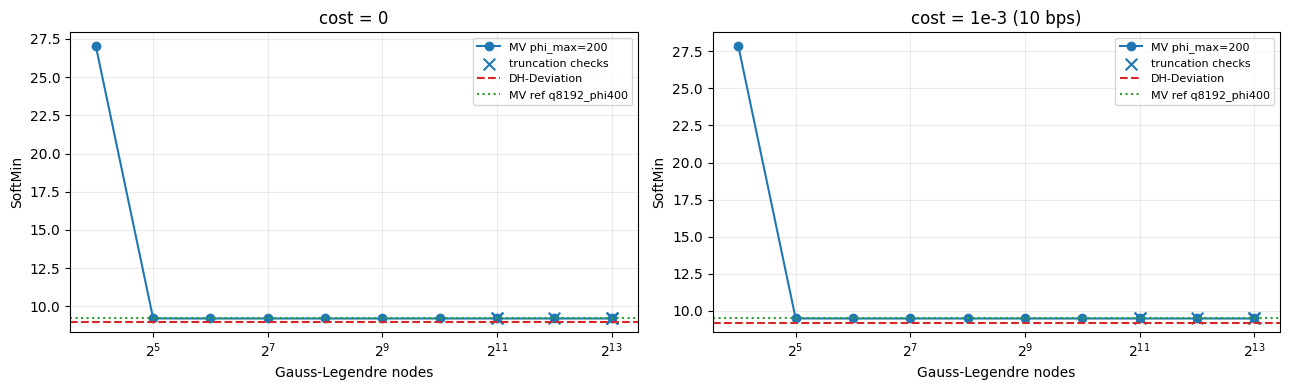

saved results_mv_budget/mv_budget_delta_rmse.png


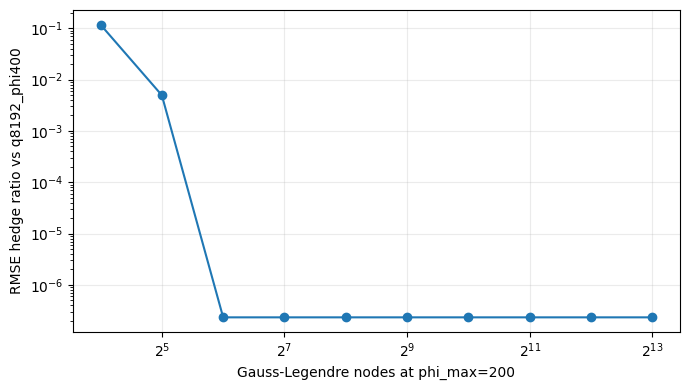

In [4]:
df = pd.read_csv(OUT_DIR / 'mv_budget_sweep.csv')
main = df[(df['kind'] == 'node_curve') & (df['phi_max'] == 200.0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, cost, title in zip(axes, [0.0, 1e-3], ['cost = 0', 'cost = 1e-3 (10 bps)']):
    sub = main[main['cost'] == cost].sort_values('n_quad')
    ax.plot(sub['n_quad'], sub['softmin'], marker='o', label='MV phi_max=200')
    trunc = df[(df['kind'] == 'truncation_check') & (df['cost'] == cost)].sort_values(['phi_max','n_quad'])
    ax.scatter(trunc['n_quad'], trunc['softmin'], marker='x', s=70, label='truncation checks')
    dh = DH_DEVIATION[cost]
    ref_soft = df[(df['label'] == ref_label) & (df['cost'] == cost)]['softmin'].iloc[0]
    ax.axhline(dh, color='tab:red', linestyle='--', label='DH-Deviation')
    ax.axhline(ref_soft, color='tab:green', linestyle=':', label=f'MV ref {ref_label}')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Gauss-Legendre nodes')
    ax.set_ylabel('SoftMin')
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plot_path = OUT_DIR / 'mv_budget_softmin_curve.png'
fig.savefig(plot_path, dpi=180)
print('saved', plot_path)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
conv = main[main['cost'] == 0.0].sort_values('n_quad')
ax.plot(conv['n_quad'], conv['rmse_delta_vs_ref'], marker='o')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Gauss-Legendre nodes at phi_max=200')
ax.set_ylabel(f'RMSE hedge ratio vs {ref_label}')
ax.grid(True, alpha=0.25)
fig.tight_layout()
plot_path = OUT_DIR / 'mv_budget_delta_rmse.png'
fig.savefig(plot_path, dpi=180)
print('saved', plot_path)
plt.show()
